In [1]:
# Core imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, kruskal
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    mean_absolute_error,
    accuracy_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

print("Environment ready.")

Environment ready.


In [2]:
# Change this only if Notebook 03 saved the feature table somewhere else.
CANDIDATE_PATHS = [
    Path("../results/section_wise_tfidf_features.csv"),
    Path("../results/section_wise_tfidf_similarity.csv"),
    Path("../data/processed/section_wise_tfidf_features.csv"),
    Path("../data/section_wise_tfidf_features.csv"),
    Path("../results/section_wise_features.csv"),
]

INPUT_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)

if INPUT_PATH is None:
    print("No saved Notebook 03 feature file was found.")
    print("Expected one of:")
    for p in CANDIDATE_PATHS:
        print("  ", p)
else:
    print("Using:", INPUT_PATH.resolve())

No saved Notebook 03 feature file was found.
Expected one of:
   ..\results\section_wise_tfidf_features.csv
   ..\results\section_wise_tfidf_similarity.csv
   ..\data\processed\section_wise_tfidf_features.csv
   ..\data\section_wise_tfidf_features.csv
   ..\results\section_wise_features.csv


In [15]:
# ============================================================
# CELL 9 — LOAD THE ACTUAL EXCEL FILES
# ============================================================

from pathlib import Path
import pandas as pd

# Notebook is running inside:
# D:\mega\academic-project-novelty-detection\notebooks
#
# Therefore the project root is one level above.

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

PROJECT_FILE = (
    DATA_DIR / "Academic_Project_Similarity_Synthetic_Dataset.xlsx"
)

PAIR_FILE = (
    DATA_DIR / "Project_Similarity_Pairs_0_to_4.xlsx"
)


# ------------------------------------------------------------
# Check paths
# ------------------------------------------------------------

print("Notebook directory:")
print(NOTEBOOK_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nProject dataset:")
print(PROJECT_FILE)
print("Exists:", PROJECT_FILE.exists())

print("\nPair dataset:")
print(PAIR_FILE)
print("Exists:", PAIR_FILE.exists())


# ------------------------------------------------------------
# Stop if files are missing
# ------------------------------------------------------------

if not PROJECT_FILE.exists():
    raise FileNotFoundError(
        f"Project dataset not found:\n{PROJECT_FILE}"
    )

if not PAIR_FILE.exists():
    raise FileNotFoundError(
        f"Pair dataset not found:\n{PAIR_FILE}"
    )


# ------------------------------------------------------------
# Inspect workbook sheets
# ------------------------------------------------------------

project_xl = pd.ExcelFile(PROJECT_FILE)
pair_xl = pd.ExcelFile(PAIR_FILE)

print("\n================ PROJECT WORKBOOK ================")
print(project_xl.sheet_names)

print("\n================ PAIR WORKBOOK ===================")
print(pair_xl.sheet_names)


# ============================================================
# LOAD ALL SIMILARITY-PAIR SHEETS
# ============================================================

pair_xl = pd.ExcelFile(PAIR_FILE)

print("Pair workbook sheets:")
print(pair_xl.sheet_names)


pair_frames = []

for sheet in pair_xl.sheet_names:

    print(f"\nLoading sheet: {sheet}")

    temp = pd.read_excel(
        PAIR_FILE,
        sheet_name=sheet
    )

    # Clean column names
    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
    )

    print("Rows:", len(temp))

    # Show label distribution in this sheet
    if "expert_similarity_label" in temp.columns:
        print(
            temp["expert_similarity_label"]
            .value_counts(dropna=False)
            .sort_index()
            .to_dict()
        )

    pair_frames.append(temp)


# Combine all sheets
pairs = pd.concat(
    pair_frames,
    ignore_index=True
)


# Remove completely duplicated rows if any
pairs = pairs.drop_duplicates().reset_index(drop=True)


print("\n===================================================")
print("COMBINED PAIR DATA")
print("===================================================")

print("Total pairs:", len(pairs))

print("\nExpert label distribution:")

display(
    pairs["expert_similarity_label"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

# ------------------------------------------------------------
# Clean column names
# ------------------------------------------------------------

projects.columns = (
    projects.columns
    .astype(str)
    .str.strip()
)

pairs.columns = (
    pairs.columns
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("\n================ PROJECT DATA ====================")

print("Shape:", projects.shape)

print("\nColumns:")
for col in projects.columns:
    print("  ", col)


print("\n================ PAIR DATA ======================")

print("Shape:", pairs.shape)

print("\nColumns:")
for col in pairs.columns:
    print("  ", col)


# ------------------------------------------------------------
# Display samples
# ------------------------------------------------------------

print("\n================ PROJECT SAMPLE =================")

display(projects.head())


print("\n================ PAIR SAMPLE ====================")

display(pairs.head())

Notebook directory:
d:\mega\academic-project-novelty-detection\notebooks

Project root:
d:\mega\academic-project-novelty-detection

Project dataset:
d:\mega\academic-project-novelty-detection\data\raw\Academic_Project_Similarity_Synthetic_Dataset.xlsx
Exists: True

Pair dataset:
d:\mega\academic-project-novelty-detection\data\raw\Project_Similarity_Pairs_0_to_4.xlsx
Exists: True

================ PROJECT WORKBOOK ================
['Projects', 'SimilarityPairs', 'DataDictionary', 'README']

================ PAIR WORKBOOK ===================
['Similarity_0', 'Similarity_1', 'Similarity_2', 'Similarity_3', 'Similarity_4']
Pair workbook sheets:
['Similarity_0', 'Similarity_1', 'Similarity_2', 'Similarity_3', 'Similarity_4']

Loading sheet: Similarity_0
Rows: 1336
{0: 1336}

Loading sheet: Similarity_1
Rows: 334
{1: 334}

Loading sheet: Similarity_2
Rows: 514
{2: 514}

Loading sheet: Similarity_3
Rows: 581
{3: 581}

Loading sheet: Similarity_4
Rows: 235
{4: 235}

COMBINED PAIR DATA
Total pa

,count
expert_similarity_label,
0,1336
1,334
2,514
3,581
4,235



================ PROJECT DATA ====================
Shape: (600, 16)

Columns:
   project_id
   academic_year
   department
   program_level
   project_status
   domain
   project_title
   abstract
   problem_statement
   objectives
   proposed_methodology
   dataset
   algorithm_model
   technology_tools
   keywords
   data_source

================ PAIR DATA ======================
Shape: (3000, 8)

Columns:
   pair_id
   project_A_id
   project_B_id
   same_semantic_family
   baseline_lexical_overlap_proxy
   expert_similarity_label
   similarity_category
   annotation_note

================ PROJECT SAMPLE =================


,project_id,academic_year,department,program_level,project_status,domain,project_title,abstract,problem_statement,objectives,proposed_methodology,dataset,algorithm_model,technology_tools,keywords,data_source
0,SYN-0001,2022-23,MCA,UG Mini Project,Completed,Artificial Intelligence & Machine Learning,Prototype Crop Disease Detection Using CNN,This project proposes a ug mini project soluti...,Existing approaches to crop disease detection ...,1) Collect and preprocess relevant data; 2) de...,Implement a lightweight detection or predictio...,PlantVillage,CNN,"Python, XGBoost","crop disease detection, AI, Machine Learning, ...",SYNTHETIC
1,SYN-0002,2026-27,MCA,UG Mini Project,Ongoing,Healthcare & Medical Informatics,Web-Based Network Intrusion Detection Using Ra...,This project proposes a ug mini project soluti...,Existing approaches to network intrusion detec...,1) Collect and preprocess relevant data; 2) de...,"Build a web-based prototype, integrate a machi...",CIC-IDS2017,Random Forest,"Python, TensorFlow","network intrusion, AI, network intrusion detec...",SYNTHETIC
2,SYN-0003,2025-26,MCA,UG Mini Project,Completed,Cybersecurity,Web-Based Phishing Website Detection Using Ran...,This project proposes a ug mini project soluti...,Existing approaches to phishing website detect...,1) Collect and preprocess relevant data; 2) de...,"Develop a prototype, preprocess the dataset, e...",Kaggle phishing dataset,Random Forest,"Python, Wazuh","AI, Machine Learning, Random Forest, phishing",SYNTHETIC
3,SYN-0004,2023-24,AI&DS,UG Mini Project,Completed,Internet of Things,Prototype Smart Home Energy Monitoring Using LSTM,This project proposes a ug mini project soluti...,Existing approaches to smart home energy monit...,1) Collect and preprocess relevant data; 2) de...,"Develop a prototype, preprocess the dataset, e...",IoT sensor dataset,LSTM,"Arduino, Node.js, MongoDB","LSTM, IoT, Machine Learning, smart home",SYNTHETIC
4,SYN-0005,2025-26,MCA,UG Mini Project,Completed,Cloud Computing,Prototype Blockchain-Based Health Record Acces...,This project proposes a ug mini project soluti...,Existing approaches to blockchain-based health...,1) Collect and preprocess relevant data; 2) de...,"Build a web-based prototype, integrate a machi...",synthetic healthcare records,Hyperledger Fabric,"Docker, Kubernetes, Python","Cloud, AI, Machine Learning, health records",SYNTHETIC



================ PAIR SAMPLE ====================


,pair_id,project_A_id,project_B_id,same_semantic_family,baseline_lexical_overlap_proxy,expert_similarity_label,similarity_category,annotation_note
0,PAIR-0001,SYN-0033,SYN-0119,0,0.7778,0,Not Similar,SYNTHETIC BENCHMARK LABEL — must be replaced/v...
1,PAIR-0002,SYN-0368,SYN-0009,0,0.6512,0,Not Similar,SYNTHETIC BENCHMARK LABEL — must be replaced/v...
2,PAIR-0003,SYN-0309,SYN-0337,0,0.7368,0,Not Similar,SYNTHETIC BENCHMARK LABEL — must be replaced/v...
3,PAIR-0004,SYN-0510,SYN-0295,0,0.7250,0,Not Similar,SYNTHETIC BENCHMARK LABEL — must be replaced/v...
4,PAIR-0007,SYN-0132,SYN-0496,0,0.6829,0,Not Similar,SYNTHETIC BENCHMARK LABEL — must be replaced/v...


In [16]:
# ============================================================
# CELL 10 — CREATE SECTION-WISE TF-IDF FEATURE DATASET
# ============================================================

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ------------------------------------------------------------
# 1. Define the eight project sections
# ------------------------------------------------------------

section_map = {
    "title_similarity": "project_title",
    "abstract_similarity": "abstract",
    "problem_similarity": "problem_statement",
    "objectives_similarity": "objectives",
    "methodology_similarity": "proposed_methodology",
    "dataset_similarity": "dataset",
    "algorithm_similarity": "algorithm_model",
    "technology_similarity": "technology_tools",
}


FEATURES = list(section_map.keys())

TARGET = "expert_similarity_label"


print("Sections to process:")
for feature, column in section_map.items():
    print(f"  {feature:25s} ← {column}")


# ------------------------------------------------------------
# 2. Clean project IDs
# ------------------------------------------------------------

projects["project_id"] = (
    projects["project_id"]
    .astype(str)
    .str.strip()
)

pairs["project_A_id"] = (
    pairs["project_A_id"]
    .astype(str)
    .str.strip()
)

pairs["project_B_id"] = (
    pairs["project_B_id"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 3. Create project ID → row index mapping
# ------------------------------------------------------------

project_id_to_index = {
    project_id: index
    for index, project_id
    in enumerate(projects["project_id"])
}


print("\nNumber of projects:", len(project_id_to_index))
print("Number of pairs:", len(pairs))


# ------------------------------------------------------------
# 4. Create base dataframe from pair dataset
# ------------------------------------------------------------

base_columns = [
    "pair_id",
    "project_A_id",
    "project_B_id",
    "same_semantic_family",
    "baseline_lexical_overlap_proxy",
    "expert_similarity_label",
    "similarity_category",
]

df = pairs[base_columns].copy()


# ------------------------------------------------------------
# 5. Convert label to numeric
# ------------------------------------------------------------

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)


# ------------------------------------------------------------
# 6. Calculate TF-IDF similarity for each section
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("CALCULATING SECTION-WISE TF-IDF SIMILARITY")
print("=" * 65)


for feature_name, source_column in section_map.items():

    print(f"\nProcessing: {source_column}")

    # --------------------------------------------------------
    # Get text
    # --------------------------------------------------------

    texts = (
        projects[source_column]
        .fillna("")
        .astype(str)
        .str.strip()
    )


    # --------------------------------------------------------
    # TF-IDF vectorization
    # --------------------------------------------------------

    vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w+\b",
        ngram_range=(1, 2),
        min_df=1
    )

    tfidf_matrix = vectorizer.fit_transform(texts)


    # --------------------------------------------------------
    # Calculate pair similarity
    # --------------------------------------------------------

    similarities = []

    missing_pairs = 0

    for project_a, project_b in zip(
        df["project_A_id"],
        df["project_B_id"]
    ):

        # Check that both project IDs exist
        if (
            project_a not in project_id_to_index
            or
            project_b not in project_id_to_index
        ):

            similarities.append(np.nan)

            missing_pairs += 1

            continue


        index_a = project_id_to_index[project_a]
        index_b = project_id_to_index[project_b]


        # Cosine similarity
        similarity = cosine_similarity(
            tfidf_matrix[index_a],
            tfidf_matrix[index_b]
        )[0, 0]


        similarities.append(similarity)


    # --------------------------------------------------------
    # Add feature
    # --------------------------------------------------------

    df[feature_name] = similarities


    # --------------------------------------------------------
    # Print statistics
    # --------------------------------------------------------

    print(
        f"  Mean       : {np.nanmean(similarities):.4f}"
    )

    print(
        f"  Median     : {np.nanmedian(similarities):.4f}"
    )

    print(
        f"  Min        : {np.nanmin(similarities):.4f}"
    )

    print(
        f"  Max        : {np.nanmax(similarities):.4f}"
    )

    print(
        f"  Missing    : {missing_pairs}"
    )


# ------------------------------------------------------------
# 7. Remove rows with missing required values
# ------------------------------------------------------------

before = len(df)

df = df.dropna(
    subset=FEATURES + [TARGET]
).reset_index(drop=True)

after = len(df)


print("\n")
print("=" * 65)
print("CLEANING SUMMARY")
print("=" * 65)

print("Rows before cleaning :", before)
print("Rows after cleaning  :", after)
print("Rows removed         :", before - after)


# ------------------------------------------------------------
# 8. Check expert-label distribution
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("EXPERT SIMILARITY LABEL DISTRIBUTION")
print("=" * 65)

label_distribution = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

label_distribution["percentage"] = (
    label_distribution["count"]
    / len(df)
    * 100
)

display(
    label_distribution.round(2)
)


# ------------------------------------------------------------
# 9. Show final feature table
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("FINAL FEATURE TABLE")
print("=" * 65)

display(
    df[
        [
            "pair_id",
            "project_A_id",
            "project_B_id",
            TARGET,
        ] + FEATURES
    ].head(10)
)


# ------------------------------------------------------------
# 10. Section-wise averages by expert label
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("SECTION-WISE MEAN SIMILARITY BY EXPERT LABEL")
print("=" * 65)

group_means = (
    df
    .groupby(TARGET)[FEATURES]
    .mean()
)

display(
    group_means.round(4)
)


# ------------------------------------------------------------
# 11. Save feature dataset
# ------------------------------------------------------------

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "feature_label_analysis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OUTPUT_FILE = (
    OUTPUT_DIR
    / "section_wise_tfidf_features.csv"
)


df.to_csv(
    OUTPUT_FILE,
    index=False
)


print("\n")
print("=" * 65)
print("SAVED")
print("=" * 65)

print(
    OUTPUT_FILE.resolve()
)

Sections to process:
  title_similarity          ← project_title
  abstract_similarity       ← abstract
  problem_similarity        ← problem_statement
  objectives_similarity     ← objectives
  methodology_similarity    ← proposed_methodology
  dataset_similarity        ← dataset
  algorithm_similarity      ← algorithm_model
  technology_similarity     ← technology_tools

Number of projects: 600
Number of pairs: 3000


CALCULATING SECTION-WISE TF-IDF SIMILARITY

Processing: project_title
  Mean       : 0.3323
  Median     : 0.1574
  Min        : 0.0032
  Max        : 1.0000
  Missing    : 0

Processing: abstract
  Mean       : 0.5371
  Median     : 0.4972
  Min        : 0.1577
  Max        : 1.0000
  Missing    : 0

Processing: problem_statement
  Mean       : 0.7165
  Median     : 0.5540
  Min        : 0.3192
  Max        : 1.0000
  Missing    : 0

Processing: objectives
  Mean       : 0.6924
  Median     : 0.5406
  Min        : 0.2784
  Max        : 1.0000
  Missing    : 0

Processi

,count,percentage
expert_similarity_label,,
0,1336,44.53
1,334,11.13
2,514,17.13
3,581,19.37
4,235,7.83




FINAL FEATURE TABLE


,pair_id,project_A_id,project_B_id,expert_similarity_label,title_similarity,abstract_similarity,problem_similarity,objectives_similarity,methodology_similarity,dataset_similarity,algorithm_similarity,technology_similarity
0,PAIR-0001,SYN-0033,SYN-0119,0,0.006180,0.298653,0.524604,0.448170,0.040158,0.000000,0.0,0.215376
1,PAIR-0002,SYN-0368,SYN-0009,0,0.004200,0.239706,0.343406,0.301153,0.045815,0.111653,0.0,0.017201
2,PAIR-0003,SYN-0309,SYN-0337,0,0.005283,0.250991,0.489985,0.441334,0.002995,0.000000,0.0,0.019750
3,PAIR-0004,SYN-0510,SYN-0295,0,0.060742,0.218413,0.421793,0.397534,0.044460,0.050648,0.0,0.024160
4,PAIR-0007,SYN-0132,SYN-0496,0,0.005337,0.226288,0.418909,0.372471,0.025036,0.000000,0.0,0.018409
5,PAIR-0008,SYN-0363,SYN-0144,0,0.004898,0.232002,0.459022,0.411117,0.042054,0.000000,0.0,0.026655
6,PAIR-0010,SYN-0553,SYN-0375,0,0.078387,0.293910,0.434467,0.387146,0.044460,0.091991,1.0,0.023641
7,PAIR-0011,SYN-0507,SYN-0227,0,0.004740,0.231081,0.499769,0.425077,0.037083,0.000000,0.0,0.000000
8,PAIR-0014,SYN-0123,SYN-0405,0,0.007991,0.281971,0.549946,0.501319,0.025036,0.000000,0.0,0.016409
9,PAIR-0025,SYN-0384,SYN-0072,0,0.073415,0.283969,0.514668,0.471486,0.068270,0.037340,0.0,0.034978




SECTION-WISE MEAN SIMILARITY BY EXPERT LABEL


,title_similarity,abstract_similarity,problem_similarity,objectives_similarity,methodology_similarity,dataset_similarity,algorithm_similarity,technology_similarity
expert_similarity_label,,,,,,,,
0,0.0395,0.2628,0.4681,0.4208,0.1544,0.0208,0.0979,0.0806
1,0.3266,0.5380,0.7149,0.6916,0.1515,0.5237,0.5216,0.0718
2,0.6285,0.8137,0.9679,0.9669,0.1372,1.0000,0.9280,0.0916
3,0.6267,0.8122,0.9670,0.9660,0.1499,1.0000,0.9260,0.0954
4,0.6285,0.8100,0.9620,0.9609,0.1271,1.0000,0.9149,0.0751




SAVED
D:\mega\academic-project-novelty-detection\results\feature_label_analysis\section_wise_tfidf_features.csv


SPEARMAN CORRELATION WITH EXPERT SIMILARITY LABEL


,feature,spearman_rho,p_value,absolute_rho
0,dataset_similarity,0.82378,0.00000,0.82378
1,abstract_similarity,0.78157,0.00000,0.78157
2,objectives_similarity,0.78105,0.00000,0.78105
3,problem_similarity,0.77802,0.00000,0.77802
4,title_similarity,0.76732,0.00000,0.76732
5,algorithm_similarity,0.74509,0.00000,0.74509
6,methodology_similarity,-0.01252,0.49314,0.01252
7,technology_similarity,0.00982,0.59081,0.00982


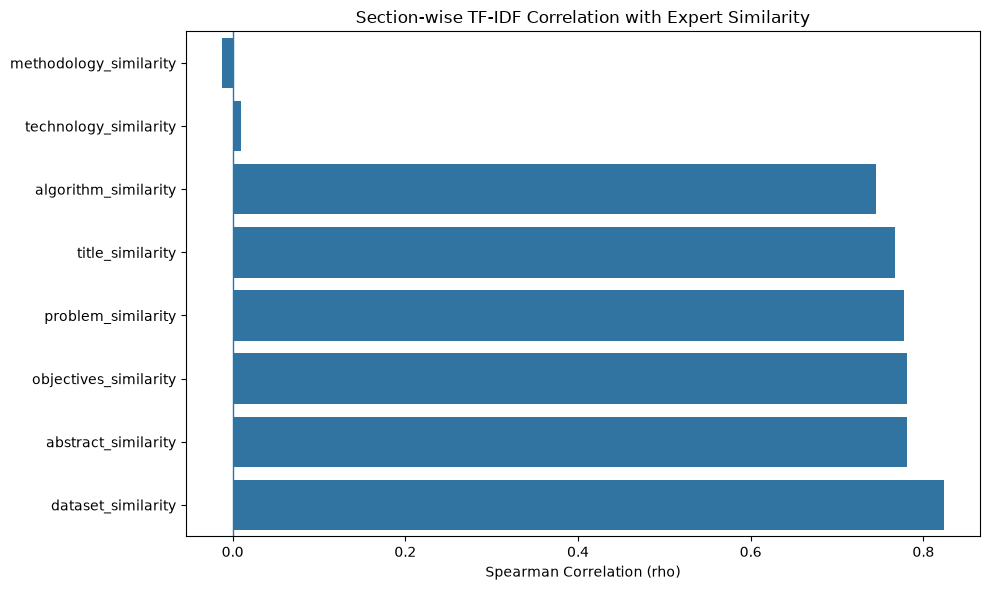

In [17]:
# ============================================================
# CELL 11 — SPEARMAN CORRELATION ANALYSIS
# ============================================================

from scipy.stats import spearmanr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


FEATURES = [
    "title_similarity",
    "abstract_similarity",
    "problem_similarity",
    "objectives_similarity",
    "methodology_similarity",
    "dataset_similarity",
    "algorithm_similarity",
    "technology_similarity",
]

TARGET = "expert_similarity_label"


# ------------------------------------------------------------
# Calculate Spearman correlation
# ------------------------------------------------------------

correlation_results = []

for feature in FEATURES:

    rho, p_value = spearmanr(
        df[feature],
        df[TARGET]
    )

    correlation_results.append({
        "feature": feature,
        "spearman_rho": rho,
        "p_value": p_value,
        "absolute_rho": abs(rho)
    })


correlation_df = pd.DataFrame(
    correlation_results
)

correlation_df = (
    correlation_df
    .sort_values(
        "absolute_rho",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("SPEARMAN CORRELATION WITH EXPERT SIMILARITY LABEL")
print("=" * 70)

display(
    correlation_df.round(5)
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plot_df = (
    correlation_df
    .sort_values("spearman_rho")
)

sns.barplot(
    data=plot_df,
    x="spearman_rho",
    y="feature"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Section-wise TF-IDF Correlation with Expert Similarity"
)

plt.xlabel(
    "Spearman Correlation (rho)"
)

plt.ylabel("")

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# CELL 12 — KRUSKAL-WALLIS TEST
# ============================================================

from scipy.stats import kruskal
import pandas as pd


FEATURES = [
    "title_similarity",
    "abstract_similarity",
    "problem_similarity",
    "objectives_similarity",
    "methodology_similarity",
    "dataset_similarity",
    "algorithm_similarity",
    "technology_similarity",
]

TARGET = "expert_similarity_label"


# ------------------------------------------------------------
# Kruskal-Wallis test
# ------------------------------------------------------------

kruskal_results = []

labels = sorted(
    df[TARGET].unique()
)


for feature in FEATURES:

    groups = [
        df.loc[
            df[TARGET] == label,
            feature
        ].values
        for label in labels
    ]

    statistic, p_value = kruskal(
        *groups
    )

    kruskal_results.append({
        "feature": feature,
        "kruskal_H": statistic,
        "p_value": p_value
    })


kruskal_df = pd.DataFrame(
    kruskal_results
)


# ------------------------------------------------------------
# Multiple-testing correction
# Bonferroni
# ------------------------------------------------------------

number_of_tests = len(kruskal_df)

kruskal_df["bonferroni_p"] = (
    kruskal_df["p_value"]
    * number_of_tests
).clip(upper=1.0)


# ------------------------------------------------------------
# Sort by statistical significance
# ------------------------------------------------------------

kruskal_df = (
    kruskal_df
    .sort_values(
        "bonferroni_p"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Significance flag
# ------------------------------------------------------------

kruskal_df["significant_0.05"] = (
    kruskal_df["bonferroni_p"] < 0.05
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 75)
print("KRUSKAL-WALLIS TEST — SECTION-WISE SIMILARITY")
print("=" * 75)

display(
    kruskal_df.round(6)
)

KRUSKAL-WALLIS TEST — SECTION-WISE SIMILARITY


,feature,kruskal_H,p_value,bonferroni_p,significant_0.05
0,title_similarity,1923.311312,0.000000,0.000000,True
1,abstract_similarity,1999.556098,0.000000,0.000000,True
2,problem_similarity,1965.133897,0.000000,0.000000,True
3,objectives_similarity,2013.980019,0.000000,0.000000,True
4,dataset_similarity,2234.975867,0.000000,0.000000,True
5,algorithm_similarity,1822.922363,0.000000,0.000000,True
6,technology_similarity,7.214729,0.124967,0.999733,False
7,methodology_similarity,5.373156,0.251106,1.000000,False


In [21]:
# ============================================================
# CELL 13 — PAIRWISE LABEL SEPARATION
# ============================================================

from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd
import numpy as np


FEATURES = [
    "title_similarity",
    "abstract_similarity",
    "problem_similarity",
    "objectives_similarity",
    "methodology_similarity",
    "dataset_similarity",
    "algorithm_similarity",
    "technology_similarity",
]

TARGET = "expert_similarity_label"

labels = sorted(
    df[TARGET].unique()
)

print("Labels being compared:", labels)


# ------------------------------------------------------------
# 1. Run pairwise Mann-Whitney U tests
# ------------------------------------------------------------

pairwise_results = []

for feature in FEATURES:

    for label_a, label_b in combinations(labels, 2):

        group_a = df.loc[
            df[TARGET] == label_a,
            feature
        ]

        group_b = df.loc[
            df[TARGET] == label_b,
            feature
        ]

        statistic, p_value = mannwhitneyu(
            group_a,
            group_b,
            alternative="two-sided"
        )

        pairwise_results.append({
            "feature": feature,
            "label_a": int(label_a),
            "label_b": int(label_b),
            "U_statistic": statistic,
            "p_value": p_value
        })


# ------------------------------------------------------------
# 2. Convert to DataFrame
# ------------------------------------------------------------

pairwise_df = pd.DataFrame(
    pairwise_results
)


# ------------------------------------------------------------
# 3. Bonferroni correction
# ------------------------------------------------------------

number_of_tests = len(pairwise_df)

pairwise_df["bonferroni_p"] = (
    pairwise_df["p_value"] * number_of_tests
).clip(upper=1.0)


# ------------------------------------------------------------
# 4. Significance
# ------------------------------------------------------------

pairwise_df["significant_0.05"] = (
    pairwise_df["bonferroni_p"] < 0.05
)


# ------------------------------------------------------------
# 5. Create readable comparison column
# ------------------------------------------------------------

pairwise_df["comparison"] = (
    pairwise_df["label_a"].astype(str)
    + " vs "
    + pairwise_df["label_b"].astype(str)
)


# ------------------------------------------------------------
# 6. Sort BEFORE selecting display columns
# ------------------------------------------------------------

pairwise_df = pairwise_df.sort_values(
    ["feature", "label_a", "label_b"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print("=" * 80)
print("PAIRWISE MANN-WHITNEY U TESTS")
print("=" * 80)

display(
    pairwise_df[
        [
            "feature",
            "label_a",
            "label_b",
            "comparison",
            "p_value",
            "bonferroni_p",
            "significant_0.05"
        ]
    ].round(6)
)

Labels being compared: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
PAIRWISE MANN-WHITNEY U TESTS


,feature,label_a,label_b,comparison,p_value,bonferroni_p,significant_0.05
0,abstract_similarity,0,1,0 vs 1,0.000000,0.0,True
1,abstract_similarity,0,2,0 vs 2,0.000000,0.0,True
2,abstract_similarity,0,3,0 vs 3,0.000000,0.0,True
3,abstract_similarity,0,4,0 vs 4,0.000000,0.0,True
4,abstract_similarity,1,2,1 vs 2,0.000000,0.0,True
...,...,...,...,...,...,...,...
75,title_similarity,1,3,1 vs 3,0.000000,0.0,True
76,title_similarity,1,4,1 vs 4,0.000000,0.0,True
77,title_similarity,2,3,2 vs 3,0.544174,1.0,False
78,title_similarity,2,4,2 vs 4,0.523815,1.0,False


In [23]:
# ============================================================
# CELL 14 — CRITICAL 2 vs 3 vs 4 ANALYSIS
# ============================================================

critical_pairs = pairwise_df[
    pairwise_df["comparison"].isin([
        "2 vs 3",
        "2 vs 4",
        "3 vs 4"
    ])
].copy()


print("=" * 80)
print("LABEL 2 vs 3 vs 4 — CRITICAL ANALYSIS")
print("=" * 80)

display(
    critical_pairs[
        [
            "feature",
            "comparison",
            "p_value",
            "bonferroni_p",
            "significant_0.05"
        ]
    ]
    .sort_values(
        ["feature", "comparison"]
    )
    .round(6)
)

LABEL 2 vs 3 vs 4 — CRITICAL ANALYSIS


,feature,comparison,p_value,bonferroni_p,significant_0.05
7,abstract_similarity,2 vs 3,0.678964,1.0,False
8,abstract_similarity,2 vs 4,0.984901,1.0,False
9,abstract_similarity,3 vs 4,0.741557,1.0,False
17,algorithm_similarity,2 vs 3,0.897918,1.0,False
18,algorithm_similarity,2 vs 4,0.530250,1.0,False
19,algorithm_similarity,3 vs 4,0.591233,1.0,False
27,dataset_similarity,2 vs 3,0.622967,1.0,False
28,dataset_similarity,2 vs 4,0.102416,1.0,False
29,dataset_similarity,3 vs 4,0.196960,1.0,False
37,methodology_similarity,2 vs 3,0.750078,1.0,False


In [24]:
# ============================================================
# CELL 15 — EFFECT SIZE ANALYSIS USING CLIFF'S DELTA
# ============================================================

from itertools import combinations
import numpy as np
import pandas as pd


FEATURES = [
    "title_similarity",
    "abstract_similarity",
    "problem_similarity",
    "objectives_similarity",
    "methodology_similarity",
    "dataset_similarity",
    "algorithm_similarity",
    "technology_similarity",
]

TARGET = "expert_similarity_label"

labels = sorted(
    df[TARGET].unique()
)


# ------------------------------------------------------------
# Cliff's Delta
# ------------------------------------------------------------

def cliffs_delta(x, y):
    """
    Calculate Cliff's Delta.

    Positive value:
        x tends to have larger values than y.

    Negative value:
        x tends to have smaller values than y.

    Interpretation:
        |delta| < 0.147   -> negligible
        |delta| < 0.33    -> small
        |delta| < 0.474   -> medium
        otherwise         -> large
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # Efficient calculation for the dataset size used here
    comparisons = x[:, None] - y[None, :]

    greater = np.sum(comparisons > 0)
    less = np.sum(comparisons < 0)

    delta = (
        (greater - less)
        / (len(x) * len(y))
    )

    return delta


# ------------------------------------------------------------
# Calculate effect sizes
# ------------------------------------------------------------

effect_results = []

for feature in FEATURES:

    for label_a, label_b in combinations(labels, 2):

        group_a = df.loc[
            df[TARGET] == label_a,
            feature
        ].values

        group_b = df.loc[
            df[TARGET] == label_b,
            feature
        ].values

        delta = cliffs_delta(
            group_a,
            group_b
        )

        effect_results.append({
            "feature": feature,
            "label_a": int(label_a),
            "label_b": int(label_b),
            "comparison": f"{label_a} vs {label_b}",
            "cliffs_delta": delta,
            "absolute_delta": abs(delta)
        })


effect_df = pd.DataFrame(
    effect_results
)


# ------------------------------------------------------------
# Effect-size interpretation
# ------------------------------------------------------------

def interpret_cliffs_delta(delta):

    magnitude = abs(delta)

    if magnitude < 0.147:
        return "negligible"

    elif magnitude < 0.33:
        return "small"

    elif magnitude < 0.474:
        return "medium"

    else:
        return "large"


effect_df["effect_interpretation"] = (
    effect_df["cliffs_delta"]
    .apply(interpret_cliffs_delta)
)


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

effect_df = (
    effect_df
    .sort_values(
        "absolute_delta",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 85)
print("CLIFF'S DELTA — EFFECT SIZE ANALYSIS")
print("=" * 85)

display(
    effect_df[
        [
            "feature",
            "comparison",
            "cliffs_delta",
            "absolute_delta",
            "effect_interpretation"
        ]
    ].round(4)
)

CLIFF'S DELTA — EFFECT SIZE ANALYSIS


,feature,comparison,cliffs_delta,absolute_delta,effect_interpretation
0,abstract_similarity,0 vs 2,-0.9994,0.9994,large
1,abstract_similarity,0 vs 3,-0.9994,0.9994,large
2,abstract_similarity,0 vs 4,-0.9991,0.9991,large
3,dataset_similarity,0 vs 2,-0.9969,0.9969,large
4,dataset_similarity,0 vs 3,-0.9968,0.9968,large
...,...,...,...,...,...
75,technology_similarity,0 vs 4,0.0068,0.0068,negligible
76,methodology_similarity,0 vs 3,0.0055,0.0055,negligible
77,algorithm_similarity,2 vs 3,0.0020,0.0020,negligible
78,abstract_similarity,2 vs 4,-0.0009,0.0009,negligible


In [26]:
# ============================================================
# CELL 16 — EFFECT SIZE: LABELS 2 vs 3 vs 4
# ============================================================

critical_effects = effect_df[
    effect_df["comparison"].isin([
        "2 vs 3",
        "2 vs 4",
        "3 vs 4"
    ])
].copy()


critical_effects = critical_effects.sort_values(
    ["feature", "comparison"]
)


print("=" * 85)
print("EFFECT SIZE — LABELS 2 vs 3 vs 4")
print("=" * 85)

display(
    critical_effects[
        [
            "feature",
            "comparison",
            "cliffs_delta",
            "absolute_delta",
            "effect_interpretation"
        ]
    ].round(4)
)

EFFECT SIZE — LABELS 2 vs 3 vs 4


,feature,comparison,cliffs_delta,absolute_delta,effect_interpretation
69,abstract_similarity,2 vs 3,0.0145,0.0145,negligible
78,abstract_similarity,2 vs 4,-0.0009,0.0009,negligible
68,abstract_similarity,3 vs 4,-0.0147,0.0147,negligible
77,algorithm_similarity,2 vs 3,0.0020,0.0020,negligible
70,algorithm_similarity,2 vs 4,0.0131,0.0131,negligible
73,algorithm_similarity,3 vs 4,0.0111,0.0111,negligible
71,dataset_similarity,2 vs 3,0.0120,0.0120,negligible
51,dataset_similarity,2 vs 4,0.0507,0.0507,negligible
54,dataset_similarity,3 vs 4,0.0388,0.0388,negligible
72,methodology_similarity,2 vs 3,-0.0111,0.0111,negligible


X shape: (3000, 8)
y shape: (3000,)

Class distribution:


,count
expert_similarity_label,
0,1336
1,334
2,514
3,581
4,235



Training samples: 2400
Testing samples : 600


TF-IDF SECTION-WISE RANDOM FOREST BASELINE
Accuracy          : 0.5533
Balanced Accuracy : 0.3454
Macro F1          : 0.3391
Weighted F1       : 0.5393
MAE               : 0.5883

Classification Report:
              precision    recall  f1-score   support

           0     0.9081    0.9625    0.9345       267
           1     0.1333    0.0597    0.0825        67
           2     0.2523    0.2621    0.2571       103
           3     0.3095    0.3362    0.3223       116
           4     0.0926    0.1064    0.0990        47

    accuracy                         0.5533       600
   macro avg     0.3392    0.3454    0.3391       600
weighted avg     0.5294    0.5533    0.5393       600



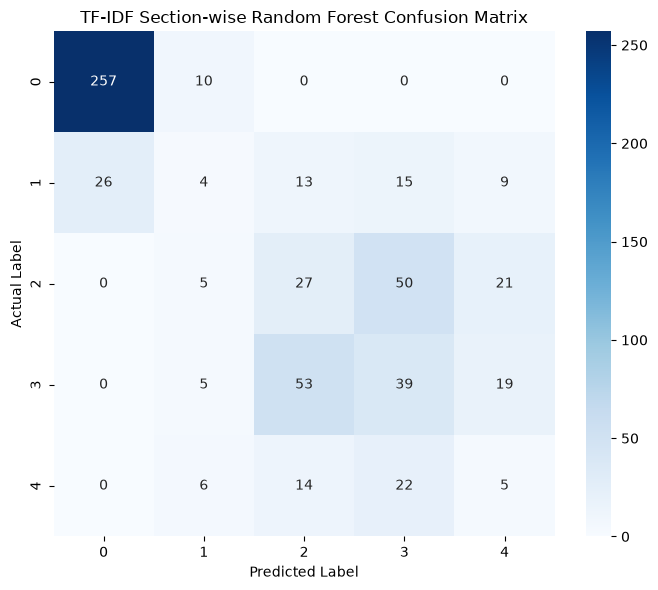

In [27]:
# ============================================================
# CELL 17 — TF-IDF SECTION-WISE CLASSIFICATION BASELINE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


FEATURES = [
    "title_similarity",
    "abstract_similarity",
    "problem_similarity",
    "objectives_similarity",
    "methodology_similarity",
    "dataset_similarity",
    "algorithm_similarity",
    "technology_similarity",
]

TARGET = "expert_similarity_label"


# ------------------------------------------------------------
# 1. Prepare X and y
# ------------------------------------------------------------

X = df[FEATURES].copy()

y = df[TARGET].astype(int)


print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
display(
    y.value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)


# ------------------------------------------------------------
# 2. Stratified train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ------------------------------------------------------------
# 3. Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    min_samples_leaf=3
)


rf_model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 4. Predictions
# ------------------------------------------------------------

y_pred = rf_model.predict(
    X_test
)


# ------------------------------------------------------------
# 5. Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

mae = mean_absolute_error(
    y_test,
    y_pred
)


print("\n")
print("=" * 70)
print("TF-IDF SECTION-WISE RANDOM FOREST BASELINE")
print("=" * 70)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")
print(f"MAE               : {mae:.4f}")


# ------------------------------------------------------------
# 6. Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


# ------------------------------------------------------------
# 7. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3, 4]
)


plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)

plt.title(
    "TF-IDF Section-wise Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()

plt.show()